# Tarea 1: Limpieza de datos

## Producción mensual de cobre de mina en Chile

En este notebook trabajo con un archivo oficial de COCHILCO sobre producción mensual de cobre de mina por empresa/faena. El archivo original viene como planilla de publicación, no como base lista para análisis, por lo que primero se ordena y limpia.

La idea es revisar la estructura del dataset, detectar problemas, generar gráficos y dejar una versión limpia que permita comparar producción nacional, Codelco y faenas relevantes como Escondida, Collahuasi y Los Pelambres.

## 1. Configuración inicial

In [1]:
from datetime import datetime
from pathlib import Path
import os
import re
import unicodedata

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd().resolve() / ".matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

cwd = Path.cwd().resolve()
if (cwd / "datos" / "originales").exists():
    BASE_DIR = cwd
elif (cwd.parent / "datos" / "originales").exists():
    BASE_DIR = cwd.parent
elif (cwd / "tarea_1_limpieza_datos" / "datos" / "originales").exists():
    BASE_DIR = cwd / "tarea_1_limpieza_datos"
else:
    BASE_DIR = Path("..").resolve()

DATA_ORIGINAL = BASE_DIR / "datos" / "originales"
DATA_LIMPIA = BASE_DIR / "datos" / "limpios"
FIGURAS = BASE_DIR / "resultados" / "figuras"

DATA_LIMPIA.mkdir(parents=True, exist_ok=True)
FIGURAS.mkdir(parents=True, exist_ok=True)

archivo = DATA_ORIGINAL / "produccion_cobre_mina_empresa_mensual.xlsx"
archivo.exists(), archivo

(True,
 PosixPath('/Users/Orvar/Documents/Ciencia de Datos Para la Economía y gestión/tarea_1_limpieza_datos/datos/originales/produccion_cobre_mina_empresa_mensual.xlsx'))

## 2. Carga del archivo original

El archivo de COCHILCO trae filas iniciales con título, unidad y fuente. Por eso se usa `header=6`, donde está la fila real de nombres de columnas.

In [2]:
df_raw = pd.read_excel(archivo, sheet_name=0, header=6)

print(df_raw.shape)
df_raw.head()

(171, 44)


,mes-año,Chuqui y R.Tomic,Chuquicamata,Radomiro Tomic,Ministro Hales,Salvador,Andina,El Teniente,Gabriela Mistral,Total Codelco,Escondida,Spence,Cerro Colorado,Lomas Bayas,Collahuasi,Los Bronces,El Soldado,Angloamerican Sur,El Abra,Candelaria,Caserones,Ojos del Salado,Mantos Blancos,Mantoverde,Capstone Copper,Los Pelambres,Zaldívar,Centinela (súlfuros),Centinela (óxidos),Antucoya,Quebrada Blanca,Andacollo,Michilla,Haldeman,Sierra Gorda,Atacama Kozan,Tres Valles,Franke,Altos de Punitaqui,Cerro Negro,Pampa Camarones,Enami (Plantas),Otros,TOTAL CHILE
0,2014-01-01 00:00:00,54.413,21.532,32.881,8.5,5.2,17.9,34.8,8.3,129.113,87.9,12.2,7.4,6.2,36.9,40.192,3.002,43.194,14.0,10.8,2.9,1.6,4.663,4.533,9.196,33.8,7.3,13.4,7.6,0.0,5.0,5.8,3.6,1.0,0.0,1.2,0.6,1.8,1.0,0.843,0.0,1.854,15.403,461.603
1,2014-02-01 00:00:00,48.554,23.154,25.400,7.3,2.5,17.1,32.9,7.3,115.654,92.5,14.2,6.8,5.6,42.8,40.035,3.305,43.340,12.8,12.1,2.7,2.2,4.420,4.202,8.622,27.8,7.1,13.2,7.7,0.0,4.4,5.9,3.1,0.9,0.0,0.9,0.5,1.6,1.1,0.648,0.0,1.569,15.083,450.816
2,2014-03-01 00:00:00,54.002,31.142,22.860,13.7,4.3,18.3,38.4,9.1,137.802,92.4,15.0,7.8,6.2,39.2,35.332,3.657,38.989,14.9,11.0,2.4,1.9,3.864,4.405,8.269,37.4,9.8,15.0,8.4,0.0,4.6,7.0,4.1,0.9,0.0,1.2,0.6,1.6,1.1,0.742,0.0,1.610,12.048,481.960
3,2014-04-01 00:00:00,48.457,29.571,18.886,16.2,3.2,19.1,29.5,9.4,125.857,104.5,12.9,6.2,6.1,41.6,32.447,3.222,35.669,14.2,10.0,0.0,2.0,3.497,4.251,7.748,35.0,9.1,16.0,8.0,0.0,3.8,5.7,4.1,0.6,0.0,0.9,0.7,1.6,0.9,0.633,0.0,1.598,15.869,471.274
4,2014-05-01 00:00:00,55.451,28.295,27.156,15.6,2.7,17.7,41.2,10.1,142.751,104.9,16.4,7.1,6.1,38.1,36.995,2.896,39.891,14.2,12.4,0.0,1.4,4.431,4.115,8.546,35.5,8.5,15.0,6.5,0.0,2.7,6.9,4.1,0.8,0.0,1.2,0.6,1.2,0.9,0.693,0.0,1.516,15.791,493.688


In [3]:
df_raw.tail()

,mes-año,Chuqui y R.Tomic,Chuquicamata,Radomiro Tomic,Ministro Hales,Salvador,Andina,El Teniente,Gabriela Mistral,Total Codelco,Escondida,Spence,Cerro Colorado,Lomas Bayas,Collahuasi,Los Bronces,El Soldado,Angloamerican Sur,El Abra,Candelaria,Caserones,Ojos del Salado,Mantos Blancos,Mantoverde,Capstone Copper,Los Pelambres,Zaldívar,Centinela (súlfuros),Centinela (óxidos),Antucoya,Quebrada Blanca,Andacollo,Michilla,Haldeman,Sierra Gorda,Atacama Kozan,Tres Valles,Franke,Altos de Punitaqui,Cerro Negro,Pampa Camarones,Enami (Plantas),Otros,TOTAL CHILE
166,2026-11-01 00:00:00,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000
167,2026-12-01 00:00:00,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000
168,2026,115.199,43.597,71.602,26.843,11.729,42.56,59.098,16.212,271.641,311.631,44.596,0.0,13.898,88.265,48.528,9.637,58.165,22.055,27.632,38.551,2.099,12.301,19.019,31.32,69.569,17.206,35.748,12.988,19.623,55.472,13.862,3.168,0.0,39.393,2.165,0.66,2.373,0.0,1.028,1.018,4.17,28.231,1216.527
169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,"Fuente / Source: COCHILCO, sobre la base de in...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Problemas iniciales detectados

Al mirar el Excel se ve que no es una base plana lista para análisis. Tiene formato de reporte, por lo que mezcla datos mensuales con elementos de presentación. Los principales problemas son:

- nombres de columnas con espacios, mayúsculas, acentos y paréntesis;
- filas de resumen anual mezcladas con observaciones mensuales;
- filas futuras o sin dato informado con producción total igual a cero;
- valores faltantes para empresas/faenas que no tienen registro en todos los meses;
- formato ancho, donde cada empresa está en una columna.


## 4. Limpieza de estructura

In [4]:
def limpiar_nombre_columna(nombre):
    texto = str(nombre).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("ascii")
    texto = re.sub(r"[^a-z0-9]+", "_", texto)
    texto = re.sub(r"_+", "_", texto).strip("_")
    return texto


df = df_raw.copy()
df = df.dropna(how="all")

columnas_limpias = {col: limpiar_nombre_columna(col) for col in df.columns}
df = df.rename(columns=columnas_limpias)
df = df.rename(columns={df.columns[0]: "fecha"})

df.columns.tolist()[:10]

['fecha',
 'chuqui_y_r_tomic',
 'chuquicamata',
 'radomiro_tomic',
 'ministro_hales',
 'salvador',
 'andina',
 'el_teniente',
 'gabriela_mistral',
 'total_codelco']

In [5]:
# Mantener solo filas mensuales. Las filas anuales vienen como numeros enteros o texto de fuente.
es_fila_mensual = df["fecha"].apply(lambda x: isinstance(x, (pd.Timestamp, datetime)))
df = df.loc[es_fila_mensual].copy()
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

columnas_numericas = [col for col in df.columns if col != "fecha"]
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.shape)
df.head()

(156, 44)


,fecha,chuqui_y_r_tomic,chuquicamata,radomiro_tomic,ministro_hales,salvador,andina,el_teniente,gabriela_mistral,total_codelco,escondida,spence,cerro_colorado,lomas_bayas,collahuasi,los_bronces,el_soldado,angloamerican_sur,el_abra,candelaria,caserones,ojos_del_salado,mantos_blancos,mantoverde,capstone_copper,los_pelambres,zaldivar,centinela_sulfuros,centinela_oxidos,antucoya,quebrada_blanca,andacollo,michilla,haldeman,sierra_gorda,atacama_kozan,tres_valles,franke,altos_de_punitaqui,cerro_negro,pampa_camarones,enami_plantas,otros,total_chile
0,2014-01-01,54.413,21.532,32.881,8.5,5.2,17.9,34.8,8.3,129.113,87.9,12.2,7.4,6.2,36.9,40.192,3.002,43.194,14.0,10.8,2.9,1.6,4.663,4.533,9.196,33.8,7.3,13.4,7.6,0.0,5.0,5.8,3.6,1.0,0.0,1.2,0.6,1.8,1.0,0.843,0.0,1.854,15.403,461.603
1,2014-02-01,48.554,23.154,25.400,7.3,2.5,17.1,32.9,7.3,115.654,92.5,14.2,6.8,5.6,42.8,40.035,3.305,43.340,12.8,12.1,2.7,2.2,4.420,4.202,8.622,27.8,7.1,13.2,7.7,0.0,4.4,5.9,3.1,0.9,0.0,0.9,0.5,1.6,1.1,0.648,0.0,1.569,15.083,450.816
2,2014-03-01,54.002,31.142,22.860,13.7,4.3,18.3,38.4,9.1,137.802,92.4,15.0,7.8,6.2,39.2,35.332,3.657,38.989,14.9,11.0,2.4,1.9,3.864,4.405,8.269,37.4,9.8,15.0,8.4,0.0,4.6,7.0,4.1,0.9,0.0,1.2,0.6,1.6,1.1,0.742,0.0,1.610,12.048,481.960
3,2014-04-01,48.457,29.571,18.886,16.2,3.2,19.1,29.5,9.4,125.857,104.5,12.9,6.2,6.1,41.6,32.447,3.222,35.669,14.2,10.0,0.0,2.0,3.497,4.251,7.748,35.0,9.1,16.0,8.0,0.0,3.8,5.7,4.1,0.6,0.0,0.9,0.7,1.6,0.9,0.633,0.0,1.598,15.869,471.274
4,2014-05-01,55.451,28.295,27.156,15.6,2.7,17.7,41.2,10.1,142.751,104.9,16.4,7.1,6.1,38.1,36.995,2.896,39.891,14.2,12.4,0.0,1.4,4.431,4.115,8.546,35.5,8.5,15.0,6.5,0.0,2.7,6.9,4.1,0.8,0.0,1.2,0.6,1.2,0.9,0.693,0.0,1.516,15.791,493.688


In [6]:
# El archivo incluye meses sin dato informado, identificables porque total_chile es 0.
filas_antes = len(df)
df = df[df["total_chile"].fillna(0) > 0].copy()
filas_eliminadas = filas_antes - len(df)

print(f"Filas eliminadas por no tener produccion informada: {filas_eliminadas}")
print(df["fecha"].min(), df["fecha"].max())
df.tail()

Filas eliminadas por no tener produccion informada: 9
2014-01-01 00:00:00 2026-03-01 00:00:00


,fecha,chuqui_y_r_tomic,chuquicamata,radomiro_tomic,ministro_hales,salvador,andina,el_teniente,gabriela_mistral,total_codelco,escondida,spence,cerro_colorado,lomas_bayas,collahuasi,los_bronces,el_soldado,angloamerican_sur,el_abra,candelaria,caserones,ojos_del_salado,mantos_blancos,mantoverde,capstone_copper,los_pelambres,zaldivar,centinela_sulfuros,centinela_oxidos,antucoya,quebrada_blanca,andacollo,michilla,haldeman,sierra_gorda,atacama_kozan,tres_valles,franke,altos_de_punitaqui,cerro_negro,pampa_camarones,enami_plantas,otros,total_chile
153,2025-11-01,54.003,26.808,27.195,13.654,4.744,17.737,24.518,7.507,122.163,94.403,17.384,0.0,5.189,37.704,14.810,3.621,18.431,6.720,7.854,13.494,1.128,5.818,7.136657,12.954657,24.670,7.828,14.933,4.349,7.502,17.736,4.429,1.187,0.0,14.791,0.897,0.307,0.900,0.0,0.365,0.400,1.536,9.495,448.749657
154,2025-12-01,79.320,49.033,30.287,20.749,11.498,24.069,28.587,8.049,172.272,111.535,19.744,0.0,5.809,36.159,13.436,3.312,16.748,7.620,11.228,15.225,1.335,5.033,10.747262,15.780262,28.777,9.391,16.713,5.308,8.211,20.859,5.487,1.456,0.0,14.860,1.067,0.278,0.832,0.0,0.403,0.362,1.526,10.176,539.161262
156,2026-01-01,38.640,13.577,25.063,8.983,4.002,15.782,18.148,5.478,91.033,104.984,16.401,0.0,4.876,30.190,15.759,3.147,18.906,7.465,10.398,13.375,0.727,4.587,4.669000,9.256000,18.959,7.458,14.005,4.697,7.113,17.469,4.950,0.979,0.0,12.954,0.819,0.272,0.915,0.0,0.362,0.347,1.368,9.677,409.955000
157,2026-02-01,32.967,13.958,19.009,9.048,3.693,8.932,21.553,3.657,79.850,105.020,11.996,0.0,4.322,26.649,15.220,3.146,18.366,6.781,9.518,11.647,0.692,3.871,6.458000,10.329000,22.927,3.996,7.372,4.015,5.707,16.787,4.300,1.039,0.0,11.521,0.796,0.209,0.736,0.0,0.261,0.348,1.353,8.855,375.392000
158,2026-03-01,43.592,16.062,27.530,8.812,4.034,17.846,19.397,7.077,100.758,101.627,16.199,0.0,4.700,31.426,17.549,3.344,20.893,7.809,7.716,13.529,0.680,3.843,7.892000,11.735000,27.683,5.752,14.371,4.276,6.803,21.216,4.612,1.150,0.0,14.918,0.550,0.179,0.722,0.0,0.405,0.323,1.449,9.699,431.180000


## 5. Características principales del dataset

In [7]:
resumen_general = pd.DataFrame({
    "metrica": ["filas", "columnas", "fecha_minima", "fecha_maxima", "duplicados"],
    "valor": [len(df), df.shape[1], df["fecha"].min(), df["fecha"].max(), df.duplicated().sum()],
})

resumen_general

,metrica,valor
0,filas,147
1,columnas,44
2,fecha_minima,2014-01-01 00:00:00
3,fecha_maxima,2026-03-01 00:00:00
4,duplicados,0


In [8]:
df[["total_chile", "total_codelco", "escondida", "collahuasi", "los_pelambres"]].describe().T

,count,mean,std,min,25%,50%,75%,max
total_chile,147.0,464.524095,34.543540,370.8417,445.3825,465.992559,486.653974,563.599572
total_codelco,147.0,129.602313,20.114325,79.8500,116.0145,132.354000,143.070000,177.667000
escondida,147.0,94.995710,17.215332,0.0000,84.7060,95.500000,105.217500,133.614000
collahuasi,147.0,44.468250,7.642847,16.9810,39.7500,44.490000,49.661000,60.316000
los_pelambres,147.0,28.984453,4.576928,14.0000,26.8525,29.400000,32.081000,38.100000


### Descripción breve de las características estadísticas

Después de la limpieza, el dataset queda con 147 observaciones mensuales y 44 columnas. El período analizado va desde enero de 2014 hasta marzo de 2026, sin filas duplicadas. La variable principal, `total_chile`, tiene una media de 464,52 miles de toneladas métricas de cobre fino y una mediana de 465,99, por lo que el nivel mensual típico de producción nacional se mueve cerca de 465 miles de toneladas. Su desviación estándar es 34,54, con un mínimo de 370,84 y un máximo de 563,60, lo que muestra variación mensual, pero dentro de un rango razonable para una serie productiva nacional.

Entre las variables seleccionadas, `total_codelco` promedia 129,60 miles de toneladas, mientras que `escondida` promedia 95,00. En faenas privadas relevantes, `collahuasi` tiene una media de 44,47 y `los_pelambres` de 28,98. Estos valores muestran que la producción está concentrada en pocos actores grandes, especialmente Codelco y Escondida, aunque varias faenas medianas también aportan al total nacional.



## 6. Valores faltantes

In [9]:
faltantes = (
    df.isna()
    .sum()
    .to_frame("n_faltantes")
    .assign(pct_faltantes=lambda x: x["n_faltantes"] / len(df) * 100)
    .sort_values("n_faltantes", ascending=False)
)

faltantes[faltantes["n_faltantes"] > 0].head(15)

,n_faltantes,pct_faltantes


Los valores faltantes no necesariamente significan un error. En este caso pueden aparecer porque una faena no operaba, no reportaba o todavía no tenía producción informada en ciertos meses. Por eso no se imputan automáticamente.

## 7. Transformación a formato largo

El Excel original queda en formato ancho: una fila por mes y una columna por faena. Para comparar faenas con mayor facilidad, también se crea una versión en formato largo, donde cada fila representa una fecha, una empresa/faena y su producción. Esta transformación no inventa datos; solo cambia la forma de organizarlos.

In [10]:
columnas_excluir = ["fecha", "total_chile", "total_codelco"]
columnas_empresas = [col for col in df.columns if col not in columnas_excluir]

df_largo = df.melt(
    id_vars="fecha",
    value_vars=columnas_empresas,
    var_name="empresa_faena",
    value_name="produccion_miles_tm_cobre_fino",
)

df_largo = df_largo.dropna(subset=["produccion_miles_tm_cobre_fino"])
df_largo = df_largo[df_largo["produccion_miles_tm_cobre_fino"] > 0].copy()
df_largo["anio"] = df_largo["fecha"].dt.year
df_largo["mes"] = df_largo["fecha"].dt.month

print(df_largo.shape)
df_largo.head()

(5694, 5)


,fecha,empresa_faena,produccion_miles_tm_cobre_fino,anio,mes
0,2014-01-01,chuqui_y_r_tomic,54.413,2014,1
1,2014-02-01,chuqui_y_r_tomic,48.554,2014,2
2,2014-03-01,chuqui_y_r_tomic,54.002,2014,3
3,2014-04-01,chuqui_y_r_tomic,48.457,2014,4
4,2014-05-01,chuqui_y_r_tomic,55.451,2014,5


In [11]:
resumen_empresas = (
    df_largo.groupby("empresa_faena")["produccion_miles_tm_cobre_fino"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

resumen_empresas.head(10)

,count,mean,median,std,min,max
empresa_faena,,,,,,
escondida,146,95.646365,95.550,15.354138,20.000,133.614
chuqui_y_r_tomic,147,51.311544,50.622,9.232582,32.258,80.030
collahuasi,147,44.468250,44.490,7.642847,16.981,60.316
el_teniente,147,35.217714,36.573,6.765020,11.534,52.428
los_pelambres,147,28.984453,29.400,4.576928,14.000,38.100
angloamerican_sur,147,28.446265,29.618,7.244083,15.557,43.340
chuquicamata,147,26.008143,24.938,8.161785,11.359,54.039
radomiro_tomic,147,25.303401,25.222,3.770316,14.149,35.318
los_bronces,147,24.834088,26.301,7.220657,11.326,40.192


> **Nota sobre la media de Escondida.** La media de Escondida difiere levemente entre tablas: en el formato ancho (sección 5, `describe()`) es `94.99` sobre 147 meses, mientras que aquí en el formato largo es `95.65` sobre 146 meses. La diferencia no es un error: en el formato largo se aplicó el filtro `produccion_miles_tm_cobre_fino > 0`, que elimina marzo de 2017, mes en que Escondida registró producción 0 (paralización por huelga). Ese 0 baja el promedio en el formato ancho, pero se conserva porque es un dato real del período, no un valor faltante.

## 8. Histogramas

Se generan dos histogramas de frecuencia porque las variables de producción son numéricas continuas y tienen muchas observaciones mensuales. El histograma es adecuado en este caso porque permite ver la forma de la distribución: dónde se concentran los valores, qué tan dispersos son y si aparecen meses o faenas alejadas del comportamiento habitual.

**Atributos elegidos:**

- `total_chile`: se elige porque resume la producción mensual nacional. El histograma permite ver cuál es el rango más frecuente de producción total y detectar meses inusualmente bajos o altos.
- `produccion_miles_tm_cobre_fino` en el dataset largo: se elige porque reúne la producción mensual positiva de cada empresa/faena. El histograma permite comparar la escala de producción entre faenas y observar si la distribución está concentrada en operaciones pequeñas/medianas o dominada por pocas faenas grandes.



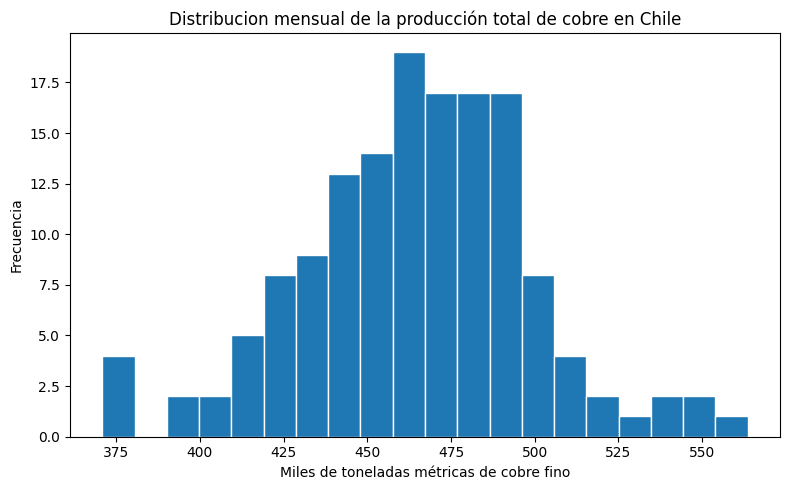

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["total_chile"], bins=20, color="#1f77b4", edgecolor="white")
ax.set_title("Distribucion mensual de la producción total de cobre en Chile")
ax.set_xlabel("Miles de toneladas métricas de cobre fino")
ax.set_ylabel("Frecuencia")
fig.tight_layout()
fig.savefig(FIGURAS / "hist_total_chile.png", dpi=150)
plt.show()

**Lectura del histograma de `total_chile`:** la producción mensual nacional se concentra cerca de los valores centrales de la serie. La tabla descriptiva muestra una media de 464,52 y una mediana de 465,99 miles de toneladas métricas, por lo que el centro de la distribución está alrededor de 465. Los extremos ayudan a identificar meses de producción especialmente baja o alta, que luego se revisan como posibles outliers.


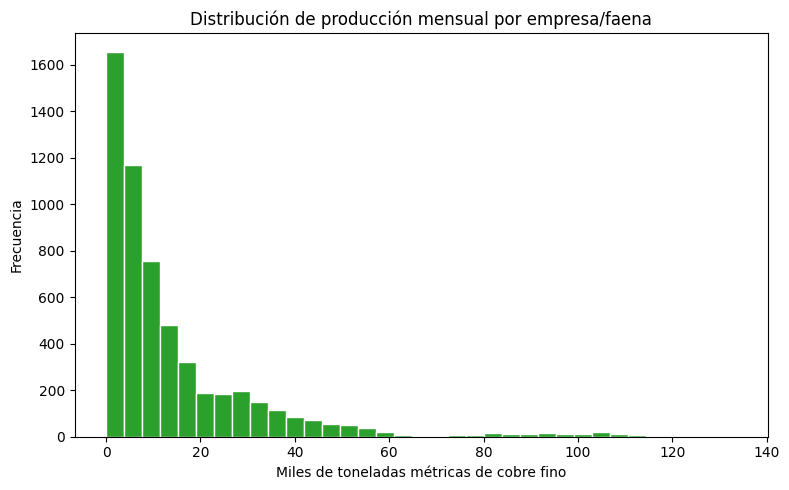

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_largo["produccion_miles_tm_cobre_fino"], bins=35, color="#2ca02c", edgecolor="white")
ax.set_title("Distribución de producción mensual por empresa/faena")
ax.set_xlabel("Miles de toneladas métricas de cobre fino")
ax.set_ylabel("Frecuencia")
fig.tight_layout()
fig.savefig(FIGURAS / "hist_empresas_faenas.png", dpi=150)
plt.show()

**Lectura del histograma por empresa/faena:** la distribución es asimétrica, porque existen muchas observaciones de baja o mediana producción y pocas observaciones muy altas. Esto es esperable en minería: algunas faenas grandes, como Escondida o Collahuasi, tienen una escala mucho mayor que otras operaciones. Por eso este histograma aporta información sobre concentración productiva entre faenas.


## 9. Diagramas de dispersión

Se generan diagramas de dispersión porque se quiere analizar la relación entre pares de variables numéricas continuas. Este tipo de gráfico es adecuado cuando interesa ver si dos variables se mueven juntas, si la relación parece positiva o negativa, si hay mucha dispersión y si existen puntos alejados del patrón general.

**Atributos elegidos:**

- `total_codelco` y `total_chile`: se eligen porque Codelco es un actor muy relevante dentro de la producción minera chilena. El diagrama permite ver si los meses con mayor producción de Codelco coinciden con meses de mayor producción nacional.
- `escondida` y `total_chile`: se eligen porque Escondida es la faena individual de mayor peso promedio en el dataset. El diagrama permite revisar si una sola faena grande se mueve de forma parecida al total nacional o si el total depende de una combinación más amplia de productores.



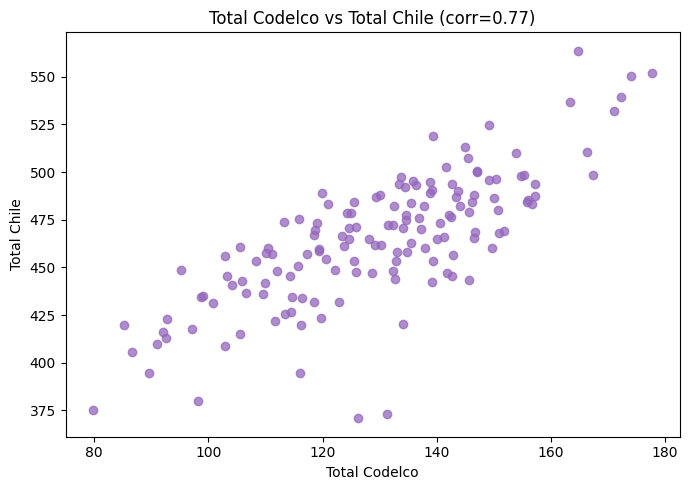

In [14]:
corr_codelco = df[["total_codelco", "total_chile"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["total_codelco"], df["total_chile"], alpha=0.75, color="#9467bd")
ax.set_title(f"Total Codelco vs Total Chile (corr={corr_codelco:.2f})")
ax.set_xlabel("Total Codelco")
ax.set_ylabel("Total Chile")
fig.tight_layout()
fig.savefig(FIGURAS / "scatter_codelco_total_chile.png", dpi=150)
plt.show()

**Lectura del scatter `total_codelco` vs `total_chile`:** la nube de puntos muestra una relación positiva. La correlación calculada es cercana a 0,77, por lo que cuando aumenta la producción agregada de Codelco, el total nacional tiende a aumentar también. Esto no prueba causalidad, pero sí confirma que Codelco se mueve de forma importante con el total país.


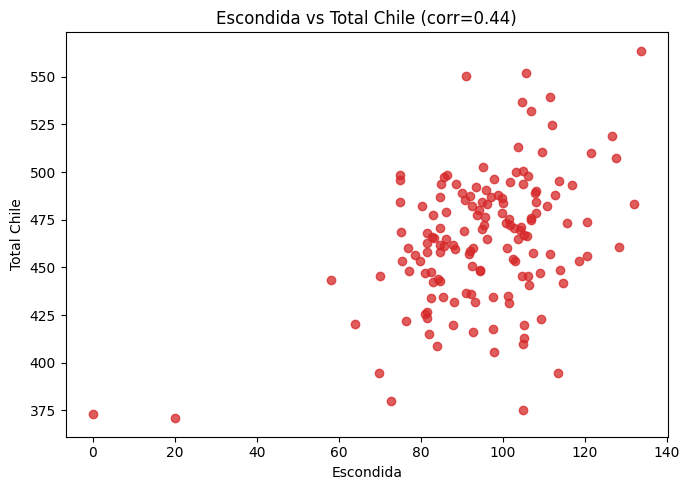

In [15]:
corr_escondida = df[["escondida", "total_chile"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["escondida"], df["total_chile"], alpha=0.75, color="#d62728")
ax.set_title(f"Escondida vs Total Chile (corr={corr_escondida:.2f})")
ax.set_xlabel("Escondida")
ax.set_ylabel("Total Chile")
fig.tight_layout()
fig.savefig(FIGURAS / "scatter_escondida_total_chile.png", dpi=150)
plt.show()

**Lectura del scatter `escondida` vs `total_chile`:** también aparece una relación positiva, pero más dispersa. La correlación es cercana a 0,44, menor que la de Codelco. Esto sugiere que Escondida influye en el total nacional, pero el total mensual de Chile depende de varias operaciones y no solo de esta faena.


## 10. Outliers, asimetría y concentración

Se evalúan outliers, asimetría y curtosis en variables productivas relevantes: `total_chile`, `total_codelco`, `escondida`, `collahuasi` y `los_pelambres`. La selección se justifica porque combinan el total nacional, un agregado institucional relevante y faenas de alto peso productivo.

- **Outliers:** permiten detectar meses inusualmente bajos o altos que podrían estar asociados a mantenciones, paralizaciones, huelgas, cambios operacionales o errores de registro.
- **Asimetría:** indica si la distribución se carga hacia valores altos o bajos.
- **Curtosis:** ayuda a evaluar la concentración de valores y la presencia de colas o valores extremos.

Estas medidas son adecuadas porque la producción minera es una variable numérica continua y puede presentar variaciones operacionales relevantes entre meses.


In [16]:
variables_interes = ["total_chile", "total_codelco", "escondida", "collahuasi", "los_pelambres"]

asimetria_concentracion = pd.DataFrame({
    "asimetria_skew": df[variables_interes].skew(),
    "curtosis_kurt": df[variables_interes].kurtosis(),
})

asimetria_concentracion

,asimetria_skew,curtosis_kurt
total_chile,-0.117567,0.688204
total_codelco,-0.131133,-0.293002
escondida,-1.526000,7.475975
collahuasi,-0.355306,0.481475
los_pelambres,-0.764225,0.910446


In [17]:
q1 = df["total_chile"].quantile(0.25)
q3 = df["total_chile"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers_total_chile = df[
    (df["total_chile"] < limite_inferior) | (df["total_chile"] > limite_superior)
][["fecha", "total_chile", "total_codelco", "escondida"]]

limite_inferior, limite_superior, outliers_total_chile

(np.float64(383.4752890000002),
 np.float64(548.5611849999998),
          fecha  total_chile  total_codelco  escondida
 40  2017-02-01   370.841700        126.173     20.000
 41  2017-03-01   373.130222        131.265      0.000
 63  2018-12-01   550.088343        174.030     91.100
 76  2019-12-01   551.750535        177.667    105.656
 118 2023-02-01   379.956940         98.232     72.704
 141 2024-12-01   563.599572        164.785    133.614
 157 2026-02-01   375.392000         79.850    105.020)

Si aparecen outliers, no conviene eliminarlos de inmediato. En minería, un mes extremo puede responder a mantenciones, paralizaciones, huelgas, cambios operacionales o cierres de período. Por eso se revisan como observaciones relevantes y no como errores automáticos.

### Resultados relevantes del análisis exploratorio

El análisis exploratorio permitió identificar atributos relevantes para seguir trabajando: `total_chile`, porque resume el comportamiento nacional; `total_codelco`, porque representa un actor agregado de gran peso; y faenas como `escondida`, `collahuasi` y `los_pelambres`, porque permiten comparar operaciones relevantes dentro del sector. Estas variables se eligieron porque combinan una mirada nacional, una mirada institucional y faenas privadas de alta producción.

En los problemas de datos, el principal hallazgo fue que el Excel original mezclaba datos mensuales con elementos de reporte. También aparecían meses futuros o sin dato efectivo: abril a diciembre de 2026 tenían `total_chile == 0`, por lo que se dejaron fuera del análisis final. Después de esa limpieza, la base ancha quedó sin valores faltantes y sin duplicados.

En outliers, usando el criterio IQR sobre `total_chile`, se detectaron meses especialmente bajos o altos, como febrero y marzo de 2017, diciembre de 2018, diciembre de 2019, febrero de 2023, diciembre de 2024 y febrero de 2026. No se eliminaron automáticamente, porque en minería estos valores pueden reflejar hechos reales como huelgas, mantenciones, paralizaciones o cambios operacionales.

En asimetría y concentración, `total_chile` muestra una asimetría leve (-0,12), por lo que la producción nacional no está extremadamente cargada hacia un lado. `Escondida`, en cambio, presenta una asimetría más negativa (-1,53) y curtosis alta (7,48), lo que indica mayor concentración y presencia de meses alejados de su comportamiento típico. El histograma por empresa/faena también muestra concentración productiva: muchas observaciones corresponden a faenas pequeñas o medianas, mientras pocas operaciones concentran producciones mensuales muy altas.



## 11. Acciones de limpieza, transformación y reducción recomendadas

A partir de los problemas detectados en el análisis exploratorio, se recomiendan las siguientes acciones sobre el dataset:

1. **Eliminar elementos que no son datos mensuales.**  
   Justificación: el archivo original venía como planilla de publicación e incluía encabezados institucionales, resúmenes anuales y nota de fuente. Esas filas no representan observaciones mensuales y pueden distorsionar el análisis.  
   Estado: implementada.

2. **Estandarizar nombres de columnas.**  
   Justificación: los nombres originales tenían mayúsculas, espacios, acentos y paréntesis. Al pasarlos a minúsculas, sin acentos y con guion bajo, el código queda más simple y menos propenso a errores.  
   Estado: implementada.

3. **Convertir tipos de datos.**  
   Justificación: la fecha debe tratarse como fecha y las producciones como variables numéricas. Sin esta conversión no se pueden calcular correctamente estadísticas, correlaciones, histogramas ni outliers.  
   Estado: implementada.

4. **Eliminar meses sin producción nacional informada (`total_chile == 0`).**  
   Justificación: abril a diciembre de 2026 aparecen con producción nacional igual a cero, lo que corresponde a meses futuros o sin dato efectivo, no a producción real igual a cero. Mantenerlos bajaría artificialmente promedios y afectaría histogramas, correlaciones y outliers.  
   Estado: implementada.

5. **Crear una versión en formato largo.**  
   Justificación: el formato ancho sirve para mirar la serie mensual, pero dificulta comparar faenas porque cada empresa está en una columna distinta. El formato largo permite agrupar, calcular promedios y ordenar faenas con mayor facilidad.  
   Estado: implementada.

6. **No eliminar outliers automáticamente.**  
   Justificación: en minería, un valor extremo puede estar asociado a huelgas, mantenciones, paralizaciones o cierres de período. Por eso se recomienda identificarlos y comentarlos, pero no borrarlos sin revisar contexto.  
   Estado: implementada como decisión analítica; los outliers se detectan, pero se conservan.

Con estas acciones se implementan más de dos medidas de limpieza y transformación: se filtran filas no válidas, se estandarizan columnas, se convierten tipos de datos, se eliminan meses sin dato nacional efectivo y se crea una versión larga del dataset.



## 12. Exportación de datos limpios

In [18]:
ruta_ancha = DATA_LIMPIA / "produccion_cobre_mensual_limpio_ancho.csv"
ruta_larga = DATA_LIMPIA / "produccion_cobre_mensual_limpio_largo.csv"
ruta_resumen = DATA_LIMPIA / "resumen_produccion_por_empresa.csv"

df.to_csv(ruta_ancha, index=False)
df_largo.to_csv(ruta_larga, index=False)
resumen_empresas.to_csv(ruta_resumen)

ruta_ancha, ruta_larga, ruta_resumen

(PosixPath('/Users/Orvar/Documents/Ciencia de Datos Para la Economía y gestión/tarea_1_limpieza_datos/datos/limpios/produccion_cobre_mensual_limpio_ancho.csv'),
 PosixPath('/Users/Orvar/Documents/Ciencia de Datos Para la Economía y gestión/tarea_1_limpieza_datos/datos/limpios/produccion_cobre_mensual_limpio_largo.csv'),
 PosixPath('/Users/Orvar/Documents/Ciencia de Datos Para la Economía y gestión/tarea_1_limpieza_datos/datos/limpios/resumen_produccion_por_empresa.csv'))

## 13. Conclusiones

Después de limpiar el archivo, el dataset queda con 147 meses válidos entre enero de 2014 y marzo de 2026. La versión ancha conserva la lógica del Excel original, mientras que la versión larga sirve mejor para comparar faenas y calcular rankings.

La producción total mensual de Chile tiene un promedio de 464,5 mil toneladas métricas de cobre fino. La serie es relativamente estable, aunque aparecen meses bajos y altos que vale la pena revisar con contexto minero.

Escondida aparece como la operación individual con mayor producción promedio positiva: 95,6 mil toneladas en meses donde produjo más que cero. Si se consideran los 147 meses del formato ancho, incluyendo marzo de 2017 con producción 0, su media es 95,0. La diferencia responde al criterio de cálculo, no a un error.

Los scatter plots muestran que `total_codelco` se relaciona más fuertemente con `total_chile` que Escondida por separado. Esto tiene sentido porque Codelco es un agregado de varias faenas, mientras que Escondida es una sola operación.

Finalmente, los outliers no se eliminaron automáticamente. En este tipo de datos pueden representar hechos reales, como mantenciones o paralizaciones, y no simples errores de registro.